<br>

<br>

# Autoscout EDA

## EDA for Car Price Prediction

<br>

<br>! Hello everyone ! <br><br>
This dataset contains many features of 9 different car models.
In this project we are going to prepare this dataset to provide an appropriate input to the ML models.<br>
Thus the steps we are going to follow ;
- Fix the corrupted data formats
- Handle with outliers and missing values.
- Drop the columns/rows you determined unnecessary as a result of your analysis.

<br>
<br> Before start analyzing first let's import the libraries we might use for further steps.

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from collections import Counter
import warnings
warnings.filterwarnings('ignore')

<br>

In [2]:
df = pd.read_json("scout_car.json", lines = True)

Even though we ussually work on a csv file, this once we are going to be working on a json file. The way that we import it is almost the same with csv file. Only the difference is "lines" parameter.

<br>

- To get an idea of what the data looks like, let's have a look at that by getting some random samples.<br><br>

- I am going to get the tranpose of it to see all the columns.

In [3]:
df.sample(3).T

,4371,10495,11060
url,https://www.autoscout24.com//offers/audi-a3-sp...,https://www.autoscout24.com//offers/opel-insig...,https://www.autoscout24.com//offers/opel-insig...
make_model,Audi A3,Opel Insignia,Opel Insignia
short_description,Sportback 1.6TDI Sport Edition 81kW,Sports Tourer 2.0 CDTI Euro6 Navi Xenon,Insigna 2.0 CDTISports Tourer/IntelliLink/Euro6
body_type,Sedans,Station wagon,Station wagon
price,16900,9500,12450
vat,None,VAT deductible,None
km,"54,740 km","222,346 km","128,980 km"
registration,01/2017,05/2016,03/2016
prev_owner,None,1 previous owner,2 previous owners
kW,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15919 entries, 0 to 15918
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            15919 non-null  object 
 1   make_model                     15919 non-null  object 
 2   short_description              15873 non-null  object 
 3   body_type                      15859 non-null  object 
 4   price                          15919 non-null  int64  
 5   vat                            11406 non-null  object 
 6   km                             15919 non-null  object 
 7   registration                   15919 non-null  object 
 8   prev_owner                     9091 non-null   object 
 9   kW                             0 non-null      float64
 10  hp                             15919 non-null  object 
 11  Type                           15917 non-null  object 
 12  Previous Owners                9279 non-null  

In [5]:
df.isnull().sum()

url                                  0
make_model                           0
short_description                   46
body_type                           60
price                                0
vat                               4513
km                                   0
registration                         0
prev_owner                        6828
kW                               15919
hp                                   0
Type                                 2
Previous Owners                   6640
Next Inspection                  12384
Inspection new                   11987
Warranty                          5420
Full Service                      7704
Non-smoking Vehicle               8742
null                                 0
Make                                 0
Model                                0
Offer Number                      3175
First Registration                1597
Body Color                         597
Paint Type                        5772
Body Color Original      

<br>I am not happy to say that but this dataset is __chaotic__ !! We have got a lot to do, better to get started.<br><br>

In [6]:
df1 = df.copy()

#### Dropping the column which have more than %50 null values.

In [7]:
df1.drop('kW', axis = 1, inplace = True)
df1.drop('Next Inspection', axis = 1, inplace = True)
df1.drop('Inspection new', axis = 1, inplace = True)
df1.drop('Non-smoking Vehicle', axis = 1, inplace = True)
df1.drop('null', axis = 1, inplace = True)
df1.drop('Model Code', axis = 1, inplace = True)
df1.drop('Emission Label', axis = 1, inplace = True)
df1.drop('Full Service', axis = 1, inplace = True)
df1.drop('Electricity consumption', axis = 1, inplace = True)
df1.drop('Last Service Date', axis = 1, inplace = True)
df1.drop('Other Fuel Types', axis = 1, inplace = True)
df1.drop('Availability', axis = 1, inplace = True)
df1.drop('Last Timing Belt Service Date', axis = 1, inplace = True)
df1.drop('Available from', axis = 1, inplace = True)
df1.drop('Country version', axis = 1, inplace = True)

<br>

- Let's shoot a glance to each column one by one.

In [8]:
df1.columns

Index(['url', 'make_model', 'short_description', 'body_type', 'price', 'vat',
       'km', 'registration', 'prev_owner', 'hp', 'Type', 'Previous Owners',
       'Warranty', 'Make', 'Model', 'Offer Number', 'First Registration',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears'],
      dtype='object')

### Url

In [9]:
df1.drop('url', axis = 1, inplace = True)

In [10]:
df1.columns

Index(['make_model', 'short_description', 'body_type', 'price', 'vat', 'km',
       'registration', 'prev_owner', 'hp', 'Type', 'Previous Owners',
       'Warranty', 'Make', 'Model', 'Offer Number', 'First Registration',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears'],
      dtype='object')

### make_model

In [11]:
df1.make_model.value_counts(dropna = False)

Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2526
Opel Corsa        2219
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: make_model, dtype: int64

In [12]:
df1.rename(columns={'make_model':'Make_Model'}, inplace = True)

### short_description

In [13]:
df1.drop('short_description', axis = 1, inplace = True)

In [14]:
df1.columns

Index(['Make_Model', 'body_type', 'price', 'vat', 'km', 'registration',
       'prev_owner', 'hp', 'Type', 'Previous Owners', 'Warranty', 'Make',
       'Model', 'Offer Number', 'First Registration', 'Body Color',
       'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears'],
      dtype='object')

### body_type

In [15]:
df1.body_type.value_counts(dropna = False)

Sedans           7903
Station wagon    3553
Compact          3153
Van               783
Other             290
Transporter        88
NaN                60
Off-Road           56
Coupe              25
Convertible         8
Name: body_type, dtype: int64

In [16]:
df1.rename(columns={'body_type':'Body_Type'}, inplace = True)

### price

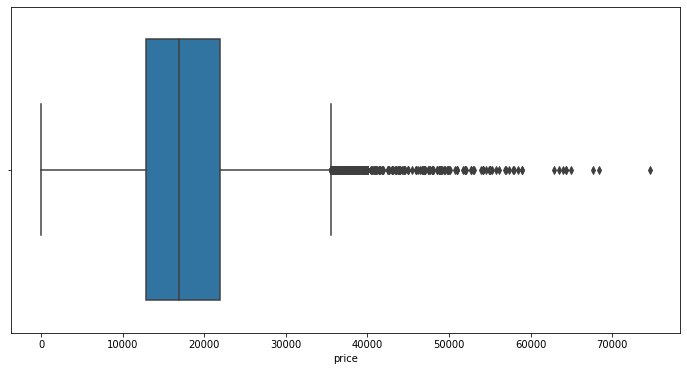

In [17]:
plt.figure(figsize = (12,6))
sns.boxplot(df1.price);

In [18]:
df1.price.sort_values().head(10)

8594       13
8828      120
6066      255
8829      331
8827     4950
8825     4990
8826     5250
8824     5300
13770    5445
8823     5450
Name: price, dtype: int64

In [19]:
df1.price.sort_values(ascending=False).head(10)

3648     74600
15826    68320
3649     67600
3587     64900
15828    64332
15831    64298
3595     63900
15833    63477
3590     62900
3594     58990
Name: price, dtype: int64

In [20]:
df1.rename(columns={'price':'Price'}, inplace = True)

### vat

In [21]:
df1.vat.value_counts(dropna = False)

VAT deductible      10980
NaN                  4513
Price negotiable      426
Name: vat, dtype: int64

In [22]:
def vat_bool (i):
        if i == "VAT deductible":
             return True
        else :
            return False

In [23]:
df1.vat = df1.vat.apply(vat_bool)

In [24]:
df1.rename(columns={'vat':'Vat_Deductible'}, inplace = True)

In [25]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'km',
       'registration', 'prev_owner', 'hp', 'Type', 'Previous Owners',
       'Warranty', 'Make', 'Model', 'Offer Number', 'First Registration',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears'],
      dtype='object')

### km

In [26]:
df1.km.value_counts()

10 km         1045
- km          1024
1 km           367
5 km           170
50 km          148
              ... 
7,123 km         1
140,387 km       1
24,939 km        1
30,460 km        1
5,903 km         1
Name: km, Length: 6690, dtype: int64

In [27]:
df1.rename(columns={'km':'Km'}, inplace = True)

In [28]:
df1.Km = df1.Km.astype('str').replace('- km', np.nan)
df1.Km  = df1.Km.str.strip(" km")
df1.Km = df1.Km.str.replace(",", "")
df1.Km = df1.Km.astype(float)

In [29]:
df1.Km

0        56013.0
1        80000.0
2        83450.0
3        73000.0
4        16200.0
          ...   
15914        NaN
15915     9900.0
15916       15.0
15917       10.0
15918        NaN
Name: Km, Length: 15919, dtype: float64

### registration & First Registration

In [30]:
df1.registration.value_counts()

-/-        1597
03/2018     695
02/2019     585
05/2018     572
03/2019     543
04/2018     541
01/2019     541
02/2018     539
03/2016     536
06/2018     532
04/2016     532
01/2018     511
04/2019     506
02/2016     472
03/2017     471
05/2016     459
06/2016     452
05/2019     440
06/2017     409
05/2017     404
07/2018     396
04/2017     380
01/2016     376
02/2017     368
01/2017     306
08/2018     285
06/2019     224
07/2017     215
11/2017     180
07/2016     176
10/2016     160
10/2017     154
09/2017     149
11/2016     142
09/2016     141
09/2018     141
12/2016     134
12/2017     123
08/2017     114
11/2018     110
12/2018     103
10/2018      97
08/2016      94
07/2019       6
09/2019       5
11/2019       1
08/2019       1
12/2019       1
Name: registration, dtype: int64

In [31]:
df1.drop('registration', axis = 1, inplace = True)

In [32]:
df1['First Registration'] = df1['First Registration'].str[1].astype('float')

In [33]:
df1['First Registration'].value_counts(dropna = False)

2018.0    4522
2016.0    3674
2017.0    3273
2019.0    2853
NaN       1597
Name: First Registration, dtype: int64

In [34]:
df1['First Registration'] = 2019 - df1['First Registration']

In [35]:
df1.rename(columns={'First Registration':'Age'}, inplace = True)

In [36]:
df1.Age.value_counts()

1.0    4522
3.0    3674
2.0    3273
0.0    2853
Name: Age, dtype: int64

In [37]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'prev_owner', 'hp', 'Type', 'Previous Owners', 'Warranty', 'Make',
       'Model', 'Offer Number', 'Age', 'Body Color', 'Paint Type',
       'Body Color Original', 'Upholstery', 'Body', 'Nr. of Doors',
       'Nr. of Seats', 'Gearing Type', 'Displacement', 'Cylinders', 'Weight',
       'Drive chain', 'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### prev_owner & Previous Owners

In [38]:
df1.prev_owner.value_counts(dropna = False)

1 previous owner     8294
NaN                  6828
2 previous owners     778
3 previous owners      17
4 previous owners       2
Name: prev_owner, dtype: int64

In [39]:
df1['Previous Owners'].value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


\n1\n                               8101
NaN                                 6640
\n2\n                                766
\n0\n                                163
\n3\n                                 17
                                    ... 
[\n0\n, \n117 g CO2/km (comb)\n]       1
[\n1\n, \n96 g CO2/km (comb)\n]        1
[\n0\n, \n187 g CO2/km (comb)\n]       1
[\n1\n, \n84 g CO2/km (comb)\n]        1
[\n1\n, \n102 g CO2/km (comb)\n]       1
Name: Previous Owners, Length: 103, dtype: int64

In [40]:
df1.drop('Previous Owners', axis = 1, inplace = True)

In [41]:
df1.prev_owner.str.strip(' previous owners').value_counts()

1    8294
2     778
3      17
4       2
Name: prev_owner, dtype: int64

In [42]:
df1.prev_owner = df1.prev_owner.str.strip(' previous owners')

In [43]:
df1.prev_owner.value_counts(dropna = False)

1      8294
NaN    6828
2       778
3        17
4         2
Name: prev_owner, dtype: int64

In [44]:
df1.rename(columns={'prev_owner':'Previous_Owners'}, inplace = True)

In [45]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'hp', 'Type', 'Warranty', 'Make', 'Model',
       'Offer Number', 'Age', 'Body Color', 'Paint Type',
       'Body Color Original', 'Upholstery', 'Body', 'Nr. of Doors',
       'Nr. of Seats', 'Gearing Type', 'Displacement', 'Cylinders', 'Weight',
       'Drive chain', 'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### hp

In [46]:
df1.hp.value_counts()

85 kW     2542
66 kW     2122
81 kW     1402
100 kW    1308
110 kW    1112
          ... 
4 kW         1
132 kW       1
84 kW        1
75 kW        1
239 kW       1
Name: hp, Length: 81, dtype: int64

In [47]:
df1.hp = df1.hp.replace('- kW', np.nan)
df1.hp = df1.hp.str.strip(" kW").astype('float')
df1.rename(columns={'hp':'kW'}, inplace = True )
df1.kW.value_counts(dropna = False)

85.0     2542
66.0     2122
81.0     1402
100.0    1308
110.0    1112
         ... 
239.0       1
115.0       1
163.0       1
4.0         1
75.0        1
Name: kW, Length: 81, dtype: int64

In [48]:
df1.kW.isnull().sum()

88

In [49]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Type', 'Warranty', 'Make', 'Model',
       'Offer Number', 'Age', 'Body Color', 'Paint Type',
       'Body Color Original', 'Upholstery', 'Body', 'Nr. of Doors',
       'Nr. of Seats', 'Gearing Type', 'Displacement', 'Cylinders', 'Weight',
       'Drive chain', 'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### Type

In [50]:
df1.Type.value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


[, Used, , Diesel (Particulate Filter)]                                                                                 3475
[, Used, , Diesel]                                                                                                      2516
[, Used, , Gasoline]                                                                                                    2367
[, Used, , Super 95]                                                                                                    1818
[, Pre-registered, , Super 95]                                                                                           500
                                                                                                                        ... 
[, Pre-registered, , CNG]                                                                                                  1
[, Used, , Others (Particulate Filter)]                                                                                    1


In [51]:
df1.Type = df1.Type.str[1]

In [52]:
df1.Type.value_counts(dropna = False)

Used              11096
New                1650
Pre-registered     1364
Employee's car     1011
Demonstration       796
NaN                   2
Name: Type, dtype: int64

In [53]:
df1.rename(columns={'Type':'Condition'}, inplace = True)

In [54]:
df1.sample(3).T

,8626,2241,5228
Make_Model,Opel Corsa,Audi A1,Audi A3
Body_Type,Sedans,Sedans,Sedans
Price,7590,21490,25500
Vat_Deductible,True,True,True
Km,47740.0,15.0,1.0
Previous_Owners,None,1,1
kW,51.0,85.0,85.0
Condition,Used,Pre-registered,Pre-registered
Warranty,NaN,"[\n60 months\n, \n111 g CO2/km (comb)\n]","[\n12 months\n, \n103 g CO2/km (comb)\n]"
Make,\nOpel\n,\nAudi\n,\nAudi\n


### Warranty

In [55]:
df1.Warranty.value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


NaN                                                                                           5420
[\n, \n, \nEuro 6\n]                                                                          1868
\n12 months\n                                                                                 1177
\n                                                                                             979
\n24 months\n                                                                                  566
                                                                                              ... 
[\n22 months\n, \n106 g CO2/km (comb)\n]                                                         1
[\n12 months\n, \n0 g CO2/km (comb)\n]                                                           1
[\n, \n, \n, 5.4 l/100 km (comb), \n, 7.1 l/100 km (city), \n, 4.4 l/100 km (country), \n]       1
[\n36 months\n, \n136 g CO2/km (comb)\n]                                                         1
[\n56 mont

In [56]:
df1["Warranty"] = df1.Warranty.apply(lambda x : x[0] if type(x)==list else x)

In [57]:
df1.Warranty.value_counts(dropna = False)
df1.Warranty = df1.Warranty.replace('\n', np.nan)

In [58]:
df1.Warranty.value_counts(dropna = False)

NaN              11065
\n12 months\n     2594
\n24 months\n     1118
\n60 months\n      401
\n36 months\n      279
\n48 months\n      149
\n6 months\n       125
\n72 months\n       59
\n3 months\n        33
\n23 months\n       11
\n18 months\n       10
\n20 months\n        7
\n25 months\n        6
\n2 months\n         5
\n50 months\n        4
\n16 months\n        4
\n26 months\n        4
\n1 months\n         3
\n13 months\n        3
\n4 months\n         3
\n34 months\n        3
\n19 months\n        3
\n46 months\n        2
\n45 months\n        2
\n11 months\n        2
\n14 months\n        2
\n28 months\n        2
\n22 months\n        2
\n17 months\n        2
\n21 months\n        2
\n9 months\n         2
\n10 months\n        1
\n30 months\n        1
\n47 months\n        1
\n33 months\n        1
\n15 months\n        1
\n65 months\n        1
\n56 months\n        1
\n7 months\n         1
                     1
\n49 months\n        1
\n40 months\n        1
\n8 months\n         1
Name: Warra

In [59]:
df1.Warranty = df1.Warranty.str.strip('\n').str.strip(' months')

In [60]:
df1.Warranty.value_counts(dropna = False)

NaN    11065
12      2594
24      1118
60       401
36       279
48       149
6        125
72        59
3         33
23        11
18        10
20         7
25         6
2          5
16         4
50         4
26         4
1          3
34         3
13         3
19         3
4          3
22         2
46         2
21         2
28         2
45         2
9          2
17         2
14         2
11         2
10         1
8          1
47         1
40         1
           1
7          1
15         1
65         1
56         1
33         1
30         1
49         1
Name: Warranty, dtype: int64

In [61]:
df1.Warranty = df1.Warranty.replace("", np.nan)

In [62]:
df1.Warranty = df1.Warranty.astype('float')

In [63]:
df1.Price.corr(df1.Warranty)

0.20352098768435753

<AxesSubplot:xlabel='Price', ylabel='Warranty'>

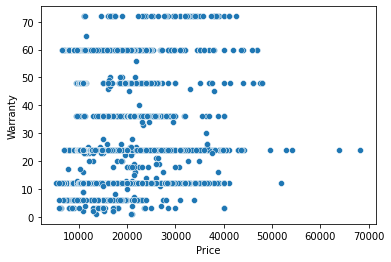

In [64]:
sns.scatterplot(y = df1.Warranty, x = df1.Price)

In [65]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Make', 'Model',
       'Offer Number', 'Age', 'Body Color', 'Paint Type',
       'Body Color Original', 'Upholstery', 'Body', 'Nr. of Doors',
       'Nr. of Seats', 'Gearing Type', 'Displacement', 'Cylinders', 'Weight',
       'Drive chain', 'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### Make - Model

- Since we have make_model column which is more than enough for us, we can drop both make and model columns.

In [66]:
df1.drop(['Make', 'Model'],axis = 1, inplace = True )

In [67]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Offer Number', 'Age',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears'],
      dtype='object')

### Offer Number

In [68]:
df1['Offer Number'].value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


NaN                3175
[\nXT61649\n]        27
[\nHM53619\n]        27
[\nTP62881\n]        27
[\nJV03654\n]        27
                   ... 
[\n9277941\n]         1
[\n19155-1\n]         1
[\n3124254\n]         1
[\nJ1109546\n]        1
[\n040394-MO\n]       1
Name: Offer Number, Length: 11441, dtype: int64

In [69]:
df1.drop('Offer Number', axis = 1, inplace = True)

In [70]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body Color',
       'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears'],
      dtype='object')

### Body Color

In [71]:
df1['Body Color'] = df1['Body Color'].str[1]

In [72]:
df1['Body Color'].value_counts(dropna = False)

Black     3745
Grey      3505
White     3406
Silver    1647
Blue      1431
Red        957
NaN        597
Brown      289
Green      154
Beige      108
Yellow      51
Violet      18
Bronze       6
Orange       3
Gold         2
Name: Body Color, dtype: int64

In [73]:
df1.rename(columns={'Body Color':'Body_Color'}, inplace = True)

### Paint Type

In [74]:
df1['Paint Type'].value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


[\nMetallic\n]       9794
NaN                  5772
[\nUni/basic\n]       347
[\nPerl effect\n]       6
Name: Paint Type, dtype: int64

In [75]:
df1['Paint Type'] = df1['Paint Type'].str[0].str.strip('\n')

In [76]:
df1.rename(columns={'Paint Type':'Paint_Type'}, inplace = True)

### Body Color Original

In [77]:
df1['Body Color Original']

0                 [\nMythosschwarz\n]
1                                 NaN
2        [\nmythosschwarz metallic\n]
3                                 NaN
4        [\nMythosschwarz Metallic\n]
                     ...             
15914              [\nGrigio scuro\n]
15915       [\nStahl-Grau Metallic\n]
15916               [\narktis-weiß\n]
15917                    [\nGrigio\n]
15918    [\nTitanium-Grau Metallic\n]
Name: Body Color Original, Length: 15919, dtype: object

In [78]:
df1.drop('Body Color Original', axis = 1, inplace = True)

In [79]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body_Color',
       'Paint_Type', 'Upholstery', 'Body', 'Nr. of Doors', 'Nr. of Seats',
       'Gearing Type', 'Displacement', 'Cylinders', 'Weight', 'Drive chain',
       'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### Upholstery

In [80]:
df1.Upholstery.str[0].value_counts(dropna = False)

\nCloth, Black\n           5821
NaN                        3720
\nPart leather, Black\n    1121
\nCloth\n                  1005
\nCloth, Grey\n             891
\nCloth, Other\n            639
\nFull leather, Black\n     575
\nBlack\n                   491
\nGrey\n                    273
\nOther, Other\n            182
\nPart leather\n            140
\nFull leather\n            139
\nFull leather, Brown\n     116
\nPart leather, Grey\n      116
\nOther, Black\n            110
\nFull leather, Other\n      72
\nFull leather, Grey\n       67
\nPart leather, Other\n      65
\nOther\n                    56
\nPart leather, Brown\n      50
\nalcantara, Black\n         47
\nVelour, Black\n            36
\nFull leather, Beige\n      36
\nCloth, Brown\n             28
\nVelour\n                   16
\nOther, Grey\n              15
\nCloth, Beige\n             13
\nBrown\n                    12
\nCloth, Blue\n              12
\nCloth, White\n              8
\nVelour, Grey\n              8
\nalcant

In [81]:
df1.Upholstery = df1.Upholstery.str[0]

In [82]:
type(df1.Upholstery[3])

float

In [83]:
df1.Upholstery = df1.Upholstery.str.strip('\n')

In [84]:
def Up_type(x):
    if type(x) != float :
        if ('Cloth' in x) or ("Cloth," in x):
            return 'Cloth'
        elif ('Part leather' in x) or ('Part leather,' in x):
            return 'Part leather'
        elif ('Full leather' in x) or ('Full leather,' in x):
            return 'Full leather'
        elif ('alcantara' in x) or ('alcantara,' in x):
            return 'Alcantara'
        elif ('Velour' in x)or ('Velour,' in x) :
            return 'Velour'
        else :
            return 'Other'
    else:
        return x

In [85]:
df1.Upholstery.apply(Up_type).value_counts(dropna = False)

Cloth           8423
NaN             3720
Part leather    1499
Other           1151
Full leather    1009
Velour            60
Alcantara         57
Name: Upholstery, dtype: int64

In [86]:
df1.Upholstery = df1.Upholstery.apply(Up_type)

In [87]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body_Color',
       'Paint_Type', 'Upholstery', 'Body', 'Nr. of Doors', 'Nr. of Seats',
       'Gearing Type', 'Displacement', 'Cylinders', 'Weight', 'Drive chain',
       'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### Body

In [88]:
df1.Body.value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


[\n, Sedans, \n]           7903
[\n, Station wagon, \n]    3553
[\n, Compact, \n]          3153
[\n, Van, \n]               783
[\n, Other, \n]             290
[\n, Transporter, \n]        88
NaN                          60
[\n, Off-Road, \n]           56
[\n, Coupe, \n]              25
[\n, Convertible, \n]         8
Name: Body, dtype: int64

In [89]:
df1.Body = df1.Body.str[1]

In [90]:
df1.rename(columns={'Body':'Body_Type'}, inplace = True)

In [91]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body_Color',
       'Paint_Type', 'Upholstery', 'Body_Type', 'Nr. of Doors', 'Nr. of Seats',
       'Gearing Type', 'Displacement', 'Cylinders', 'Weight', 'Drive chain',
       'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### Nr. of Doors & Nr. of Seats

In [92]:
df1['Nr. of Doors']

0        [\n5\n]
1        [\n3\n]
2        [\n4\n]
3        [\n3\n]
4        [\n5\n]
          ...   
15914    [\n5\n]
15915    [\n5\n]
15916    [\n5\n]
15917    [\n5\n]
15918    [\n5\n]
Name: Nr. of Doors, Length: 15919, dtype: object

In [93]:
df1.rename(columns={'Nr. of Doors':'Nr_of_Doors'}, inplace = True)
df1.Nr_of_Doors = df1.Nr_of_Doors.apply(lambda item: item[0] if type(item) == list else item)
df1.Nr_of_Doors = df1.Nr_of_Doors.str.strip('\n')
df1.Nr_of_Doors.value_counts()

5    11575
4     3079
3      832
2      219
1        1
7        1
Name: Nr_of_Doors, dtype: int64

In [94]:
df1['Nr. of Seats']

0        [\n5\n]
1        [\n4\n]
2        [\n4\n]
3        [\n4\n]
4        [\n5\n]
          ...   
15914    [\n5\n]
15915    [\n5\n]
15916    [\n7\n]
15917    [\n7\n]
15918    [\n5\n]
Name: Nr. of Seats, Length: 15919, dtype: object

In [95]:
df1.rename(columns={'Nr. of Seats':'Nr_of_Seats'}, inplace = True)
df1.Nr_of_Seats = df1.Nr_of_Seats.apply(lambda item: item[0] if type(item) == list else item)
df1.Nr_of_Seats = df1.Nr_of_Seats.str.strip('\n')
df1.Nr_of_Seats.value_counts()

5    13336
4     1125
7      362
2      116
6        2
3        1
Name: Nr_of_Seats, dtype: int64

In [96]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body_Color',
       'Paint_Type', 'Upholstery', 'Body_Type', 'Nr_of_Doors', 'Nr_of_Seats',
       'Gearing Type', 'Displacement', 'Cylinders', 'Weight', 'Drive chain',
       'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### Gearing Type

In [97]:
df1['Gearing Type']

0        [\n, Automatic, \n]
1        [\n, Automatic, \n]
2        [\n, Automatic, \n]
3        [\n, Automatic, \n]
4        [\n, Automatic, \n]
                ...         
15914    [\n, Automatic, \n]
15915    [\n, Automatic, \n]
15916    [\n, Automatic, \n]
15917    [\n, Automatic, \n]
15918    [\n, Automatic, \n]
Name: Gearing Type, Length: 15919, dtype: object

In [98]:
df1.rename(columns={'Gearing Type':'Gearing_Type'}, inplace = True)
df1.Gearing_Type = df1.Gearing_Type.apply(lambda item: item[1] if type(item) == list else item)
df1.Gearing_Type = df1.Gearing_Type.str.strip('\n')
df1.Gearing_Type.value_counts()

Manual            8153
Automatic         7297
Semi-automatic     469
Name: Gearing_Type, dtype: int64

### Displacement

In [99]:
df1.Displacement

0        [\n1,422 cc\n]
1        [\n1,798 cc\n]
2        [\n1,598 cc\n]
3        [\n1,422 cc\n]
4        [\n1,422 cc\n]
              ...      
15914    [\n1,997 cc\n]
15915    [\n1,798 cc\n]
15916    [\n1,997 cc\n]
15917    [\n1,997 cc\n]
15918    [\n1,798 cc\n]
Name: Displacement, Length: 15919, dtype: object

In [100]:
df1.Displacement = df1.Displacement.apply(lambda item: item[0] if type(item) == list else item)
df1.Displacement = df1.Displacement.str.strip('\n').str.strip(' cc\n')
df1.Displacement  = df1.Displacement.str.replace(',','')
df1.Displacement=df1.Displacement.astype(float)
df1.Displacement

0        1422.0
1        1798.0
2        1598.0
3        1422.0
4        1422.0
          ...  
15914    1997.0
15915    1798.0
15916    1997.0
15917    1997.0
15918    1798.0
Name: Displacement, Length: 15919, dtype: float64

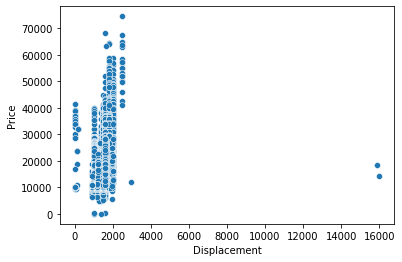

In [101]:
sns.scatterplot(y = df1.Price, x = df1.Displacement);

In [102]:
df1.Price.corr(df1.Displacement)

0.21981056590870118

### Cylinders

In [103]:
df1.Cylinders

0        [\n3\n]
1        [\n4\n]
2            NaN
3        [\n3\n]
4        [\n3\n]
          ...   
15914    [\n4\n]
15915    [\n4\n]
15916    [\n4\n]
15917    [\n4\n]
15918    [\n4\n]
Name: Cylinders, Length: 15919, dtype: object

In [104]:
df1.Cylinders = df1.Cylinders.str[0].str.strip('\n').astype(float)
df1.Cylinders

0        3.0
1        4.0
2        NaN
3        3.0
4        3.0
        ... 
15914    4.0
15915    4.0
15916    4.0
15917    4.0
15918    4.0
Name: Cylinders, Length: 15919, dtype: float64

### Weight

In [105]:
df1.Weight

0        [\n1,220 kg\n]
1        [\n1,255 kg\n]
2                   NaN
3        [\n1,195 kg\n]
4                   NaN
              ...      
15914    [\n1,758 kg\n]
15915    [\n1,708 kg\n]
15916               NaN
15917    [\n1,758 kg\n]
15918    [\n1,685 kg\n]
Name: Weight, Length: 15919, dtype: object

In [106]:
df1.Weight = df1.Weight.str[0].str.strip('\n').str.strip(" kg").str.replace(",","")

In [107]:
df1.Weight = df1.Weight.astype('float')

In [108]:
df1.Price.corr(df1.Weight)

0.4196612204899822

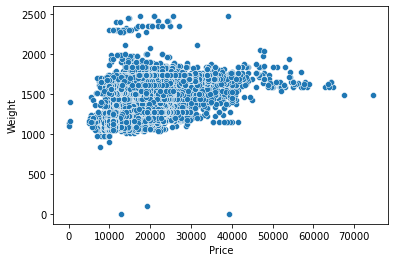

In [109]:
sns.scatterplot(x = df1.Price, y = df1.Weight);

In [110]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body_Color',
       'Paint_Type', 'Upholstery', 'Body_Type', 'Nr_of_Doors', 'Nr_of_Seats',
       'Gearing_Type', 'Displacement', 'Cylinders', 'Weight', 'Drive chain',
       'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### Drive Chain

In [111]:
df1['Drive chain']

0        [\nfront\n]
1        [\nfront\n]
2        [\nfront\n]
3                NaN
4        [\nfront\n]
            ...     
15914    [\nfront\n]
15915    [\nfront\n]
15916    [\nfront\n]
15917    [\nfront\n]
15918      [\n4WD\n]
Name: Drive chain, Length: 15919, dtype: object

In [112]:
df1.rename(columns={'Drive chain':'Drive_Chain'}, inplace = True)
df1.Drive_Chain = df1.Drive_Chain.str[0].str.strip('\n')
df1.Drive_Chain

0        front
1        front
2        front
3          NaN
4        front
         ...  
15914    front
15915    front
15916    front
15917    front
15918      4WD
Name: Drive_Chain, Length: 15919, dtype: object

### Fuel

In [113]:
df1.Fuel

0                    [\n, Diesel (Particulate Filter), \n]
1                                       [\n, Gasoline, \n]
2                    [\n, Diesel (Particulate Filter), \n]
3                    [\n, Diesel (Particulate Filter), \n]
4                    [\n, Diesel (Particulate Filter), \n]
                               ...                        
15914                [\n, Diesel (Particulate Filter), \n]
15915    [\n, Super 95 / Super Plus 98 (Particulate Fil...
15916                                     [\n, Diesel, \n]
15917                                     [\n, Diesel, \n]
15918                                   [\n, Super 95, \n]
Name: Fuel, Length: 15919, dtype: object

In [114]:
df1.Fuel = df1.Fuel.str[1]

In [115]:
def Fuel_type(x):
    if "Benzine" in x :
        return "Gasoline"
    elif "Gasoline" in x :
        return "Gasoline"
    elif "Super" in x :
        return "Gasoline"
    elif "Diesel" in x :
        return "Diesel"
    elif "LPG" in x :
        return "LPG"
    else :
        return "Others"

In [116]:
df1.Fuel = df1.Fuel.apply(Fuel_type)
df1.Fuel.value_counts()

Gasoline    8549
Diesel      7299
Others        45
LPG           26
Name: Fuel, dtype: int64

### Consumption 

In [117]:
df1.Consumption

0        [[3.8 l/100 km (comb)], [4.3 l/100 km (city)],...
1        [[5.6 l/100 km (comb)], [7.1 l/100 km (city)],...
2        [[3.8 l/100 km (comb)], [4.4 l/100 km (city)],...
3        [[3.8 l/100 km (comb)], [4.3 l/100 km (city)],...
4        [[4.1 l/100 km (comb)], [4.6 l/100 km (city)],...
                               ...                        
15914    [[5.3 l/100 km (comb)], [6.2 l/100 km (city)],...
15915    [\n, 7.4 l/100 km (comb), \n, 9.2 l/100 km (ci...
15916    [[5.3 l/100 km (comb)], [6.2 l/100 km (city)],...
15917    [[5.3 l/100 km (comb)], [6.2 l/100 km (city)],...
15918    [[6.8 l/100 km (comb)], [8.7 l/100 km (city)],...
Name: Consumption, Length: 15919, dtype: object

In [118]:
df1.Consumption = df1.Consumption.str[0]

In [119]:
df1.Consumption = df1.Consumption.str[0].str.split().str[0].astype('float')

In [120]:
df1.rename(columns={'Consumption':'Combined_Cons'}, inplace = True)

In [121]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body_Color',
       'Paint_Type', 'Upholstery', 'Body_Type', 'Nr_of_Doors', 'Nr_of_Seats',
       'Gearing_Type', 'Displacement', 'Cylinders', 'Weight', 'Drive_Chain',
       'Fuel', 'Combined_Cons', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

In [122]:
df1.Price.corr(df1.Combined_Cons)

0.16634679155003088

In [123]:
df1.Combined_Cons.value_counts()

3.9     732
4.0     712
5.4     663
5.1     630
4.4     595
       ... 
1.2       1
7.5       1
9.1       1
1.0       1
55.0      1
Name: Combined_Cons, Length: 71, dtype: int64

### CO2 Emission

In [124]:
df1['CO2 Emission']

0         [\n99 g CO2/km (comb)\n]
1        [\n129 g CO2/km (comb)\n]
2         [\n99 g CO2/km (comb)\n]
3         [\n99 g CO2/km (comb)\n]
4        [\n109 g CO2/km (comb)\n]
                   ...            
15914    [\n139 g CO2/km (comb)\n]
15915    [\n168 g CO2/km (comb)\n]
15916    [\n139 g CO2/km (comb)\n]
15917    [\n139 g CO2/km (comb)\n]
15918    [\n153 g CO2/km (comb)\n]
Name: CO2 Emission, Length: 15919, dtype: object

In [125]:
df1['CO2 Emission'] = df1['CO2 Emission'].str[0].str.split().str[0]

In [126]:
df1['CO2 Emission'] = df1['CO2 Emission'].str.replace(',', "").astype('float')

In [127]:
df1['CO2 Emission']

0         99.0
1        129.0
2         99.0
3         99.0
4        109.0
         ...  
15914    139.0
15915    168.0
15916    139.0
15917    139.0
15918    153.0
Name: CO2 Emission, Length: 15919, dtype: float64

In [128]:
df1.rename(columns={'CO2 Emission':'CO2_Emission'}, inplace = True)

In [129]:
df1.Price.corr(df1['CO2_Emission'])

0.022708603143406437

In [130]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body_Color',
       'Paint_Type', 'Upholstery', 'Body_Type', 'Nr_of_Doors', 'Nr_of_Seats',
       'Gearing_Type', 'Displacement', 'Cylinders', 'Weight', 'Drive_Chain',
       'Fuel', 'Combined_Cons', 'CO2_Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

### Emission Class

In [131]:
df1['Emission Class']

0              [\nEuro 6\n]
1              [\nEuro 6\n]
2              [\nEuro 6\n]
3              [\nEuro 6\n]
4              [\nEuro 6\n]
                ...        
15914                   NaN
15915                   NaN
15916    [\nEuro 6d-TEMP\n]
15917          [\nEuro 6\n]
15918          [\nEuro 6\n]
Name: Emission Class, Length: 15919, dtype: object

In [132]:
df1['Emission Class'] = df1['Emission Class'].str[0].str.strip("\n")

In [133]:
df1['Emission Class'].value_counts()

Euro 6          10139
Euro 6d-TEMP     1845
Euro 6c           127
Euro 5             78
Euro 6d            62
Euro 4             40
Name: Emission Class, dtype: int64

In [134]:
#df1.replace({"Emission_Class" : {"Euro 6d-TEMP":"Euro 6", "Euro 6c":"Euro 6", "Euro 6d":"Euro 6"}}, regex = True, inplace = True)

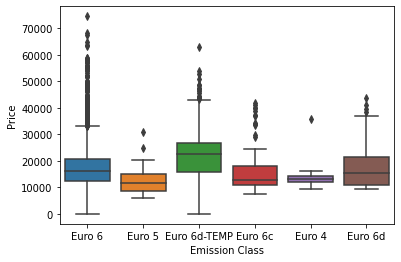

In [135]:
sns.boxplot(df1['Emission Class'],df1.Price);

In [136]:
df1.rename(columns={'Emission Class':'Emission_Class'}, inplace = True)

In [137]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body_Color',
       'Paint_Type', 'Upholstery', 'Body_Type', 'Nr_of_Doors', 'Nr_of_Seats',
       'Gearing_Type', 'Displacement', 'Cylinders', 'Weight', 'Drive_Chain',
       'Fuel', 'Combined_Cons', 'CO2_Emission', 'Emission_Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears'],
      dtype='object')

In [138]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15919 entries, 0 to 15918
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Make_Model               15919 non-null  object 
 1   Body_Type                15859 non-null  object 
 2   Price                    15919 non-null  int64  
 3   Vat_Deductible           15919 non-null  bool   
 4   Km                       14895 non-null  float64
 5   Previous_Owners          9091 non-null   object 
 6   kW                       15831 non-null  float64
 7   Condition                15917 non-null  object 
 8   Warranty                 4853 non-null   float64
 9   Age                      14322 non-null  float64
 10  Body_Color               15322 non-null  object 
 11  Paint_Type               10147 non-null  object 
 12  Upholstery               12199 non-null  object 
 13  Body_Type                15859 non-null  object 
 14  Nr_of_Doors           

In [139]:
df1["Comfort_Convenience"] = df1["\nComfort & Convenience\n"]
df1["Entertainment_Media"] = df1["\nEntertainment & Media\n"]
df1["Extras"] = df1["\nExtras\n"]
df1["Safety_Security"] = df1["\nSafety & Security\n"]

In [140]:
drop_columns = ["\nComfort & Convenience\n","\nEntertainment & Media\n","\nExtras\n","\nSafety & Security\n"]
df1.drop(drop_columns, axis = 1, inplace = True)

In [141]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Condition', 'Warranty', 'Age', 'Body_Color',
       'Paint_Type', 'Upholstery', 'Body_Type', 'Nr_of_Doors', 'Nr_of_Seats',
       'Gearing_Type', 'Displacement', 'Cylinders', 'Weight', 'Drive_Chain',
       'Fuel', 'Combined_Cons', 'CO2_Emission', 'Emission_Class',
       'description', 'Gears', 'Comfort_Convenience', 'Entertainment_Media',
       'Extras', 'Safety_Security'],
      dtype='object')

### Description

In [142]:
df1.description

0        [\n, Sicherheit:,  , Deaktivierung für Beifahr...
1        [\nLangstreckenfahrzeug daher die hohe Kilomet...
2        [\n, Fahrzeug-Nummer: AM-95365,  , Ehem. UPE 2...
3        [\nAudi A1: , - 1e eigenaar , - Perfecte staat...
4        [\n, Technik & Sicherheit:, Xenon plus, Klimaa...
                               ...                        
15914    [\nVettura visionabile nella sede in Via Roma ...
15915    [\nDach: Panorama-Glas-Schiebedach, Lackierung...
15916    [\n, Getriebe:,  Automatik, Technik:,  Bordcom...
15917    [\nDEK:[2691331], Renault Espace Blue dCi 200C...
15918    [\n, Sicherheit Airbags:,  , Seitenairbag,  , ...
Name: description, Length: 15919, dtype: object

In [143]:
df1.drop('description', axis = 1, inplace = True)

### Gears

In [144]:
df1.Gears.value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


[\n6\n]     5822
NaN         4712
[\n5\n]     3239
[\n7\n]     1908
[\n8\n]      224
[\n9\n]        6
[\n4\n]        2
[\n3\n]        2
[\n1\n]        2
[\n50\n]       1
[\n2\n]        1
Name: Gears, dtype: int64

In [145]:
df1.Gears = df1.Gears.str[0].str.strip("\n").astype('float')

In [146]:
df1.Gears.value_counts()

6.0     5822
5.0     3239
7.0     1908
8.0      224
9.0        6
4.0        2
1.0        2
3.0        2
50.0       1
2.0        1
Name: Gears, dtype: int64

### Comfort_Convenience

In [154]:
df1.Comfort_Convenience

0        [Air conditioning, Armrest, Automatic climate ...
1        [Air conditioning, Automatic climate control, ...
2        [Air conditioning, Cruise control, Electrical ...
3        [Air suspension, Armrest, Auxiliary heating, E...
4        [Air conditioning, Armrest, Automatic climate ...
                               ...                        
15914    [Air conditioning, Automatic climate control, ...
15915    [Air conditioning, Automatic climate control, ...
15916    [Air conditioning, Armrest, Automatic climate ...
15917    [Air conditioning, Automatic climate control, ...
15918    [Air conditioning, Automatic climate control, ...
Name: Comfort_Convenience, Length: 15919, dtype: object

In [155]:
df1["Comfort_Convenience"] = [",".join(item) if type(item) == list else item for item in df1["Comfort_Convenience"]]

df1["Comfort_Convenience"].value_counts(dropna=False)

NaN                                                                                                                                                                                                                                                                                                                                                                                                                                     920
Air conditioning,Electrical side mirrors,Hill Holder,Power windows                                                                                                                                                                                                                                                                                                                                                                      216
Air conditioning,Electrical side mirrors,Power windows                                                                                          

### Entertainment_Media

In [168]:
df1["Entertainment_Media"].value_counts(dropna=False).head()

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


NaN                                                                                 1374
[Bluetooth, Hands-free equipment, On-board computer, Radio, USB]                    1282
[Bluetooth, Hands-free equipment, MP3, On-board computer, Radio, USB]                982
[Bluetooth, CD player, Hands-free equipment, MP3, On-board computer, Radio, USB]     783
[On-board computer, Radio]                                                           487
Name: Entertainment_Media, dtype: int64

In [169]:
df1["Entertainment_Media"] = [",".join(item) if type(item) == list else item for item in df1["Entertainment_Media"]]
df1["Entertainment_Media"].value_counts(dropna=False).head()

NaN                                                                         1374
Bluetooth,Hands-free equipment,On-board computer,Radio,USB                  1282
Bluetooth,Hands-free equipment,MP3,On-board computer,Radio,USB               982
Bluetooth,CD player,Hands-free equipment,MP3,On-board computer,Radio,USB     783
On-board computer,Radio                                                      487
Name: Entertainment_Media, dtype: int64

### Extras

In [171]:
df1["Extras"].value_counts(dropna=False).head()

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


[Alloy wheels]                                 3245
NaN                                            2962
[Alloy wheels, Touch screen]                    697
[Alloy wheels, Voice Control]                   577
[Alloy wheels, Touch screen, Voice Control]     541
Name: Extras, dtype: int64

In [173]:
df1["Extras"] = [",".join(item) if type(item) == list else item for item in df1["Extras"]]
df1["Extras"].value_counts(dropna=False).head()

Alloy wheels                               3245
NaN                                        2962
Alloy wheels,Touch screen                   697
Alloy wheels,Voice Control                  577
Alloy wheels,Touch screen,Voice Control     541
Name: Extras, dtype: int64

### Safety_Security

In [175]:
df1["Safety_Security"].value_counts(dropna=False).head()

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


NaN                                                                                                                                                                                                                                                                       982
[ABS, Central door lock, Daytime running lights, Driver-side airbag, Electronic stability control, Fog lights, Immobilizer, Isofix, Passenger-side airbag, Power steering, Side airbag, Tire pressure monitoring system, Traction control]                                538
[ABS, Central door lock, Daytime running lights, Driver-side airbag, Electronic stability control, Immobilizer, Isofix, Passenger-side airbag, Power steering, Side airbag, Tire pressure monitoring system, Traction control]                                            480
[ABS, Central door lock, Daytime running lights, Driver-side airbag, Electronic stability control, Immobilizer, Isofix, Passenger-side airbag, Power steering, Side airbag, Tire pressure moni

In [176]:
df1["Safety_Security"] = [",".join(item) if type(item) == list else item for item in df1["Safety_Security"]]
df1["Safety_Security"].value_counts(dropna=False).head()

NaN                                                                                                                                                                                                                                                        982
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Fog lights,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control                               538
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control                                          480
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control,Xenon headlights         

<br>

---

In [178]:
df.shape

(15919, 54)

In [177]:
df1.shape

(15919, 30)

In [179]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15919 entries, 0 to 15918
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Make_Model           15919 non-null  object 
 1   Body_Type            15859 non-null  object 
 2   Price                15919 non-null  int64  
 3   Vat_Deductible       15919 non-null  bool   
 4   Km                   14895 non-null  float64
 5   Previous_Owners      9091 non-null   object 
 6   kW                   15831 non-null  float64
 7   Condition            15917 non-null  object 
 8   Warranty             4853 non-null   float64
 9   Age                  14322 non-null  float64
 10  Body_Color           15322 non-null  object 
 11  Paint_Type           10147 non-null  object 
 12  Upholstery           12199 non-null  object 
 13  Body_Type            15859 non-null  object 
 14  Nr_of_Doors          15707 non-null  object 
 15  Nr_of_Seats          14942 non-null 

In [180]:
df1.isnull().sum()

Make_Model                 0
Body_Type                 60
Price                      0
Vat_Deductible             0
Km                      1024
Previous_Owners         6828
kW                        88
Condition                  2
Warranty               11066
Age                     1597
Body_Color               597
Paint_Type              5772
Upholstery              3720
Body_Type                 60
Nr_of_Doors              212
Nr_of_Seats              977
Gearing_Type               0
Displacement             496
Cylinders               5680
Weight                  6974
Drive_Chain             6858
Fuel                       0
Combined_Cons           2883
CO2_Emission            2436
Emission_Class          3628
Gears                   4712
Comfort_Convenience      920
Entertainment_Media     1374
Extras                  2962
Safety_Security          982
dtype: int64

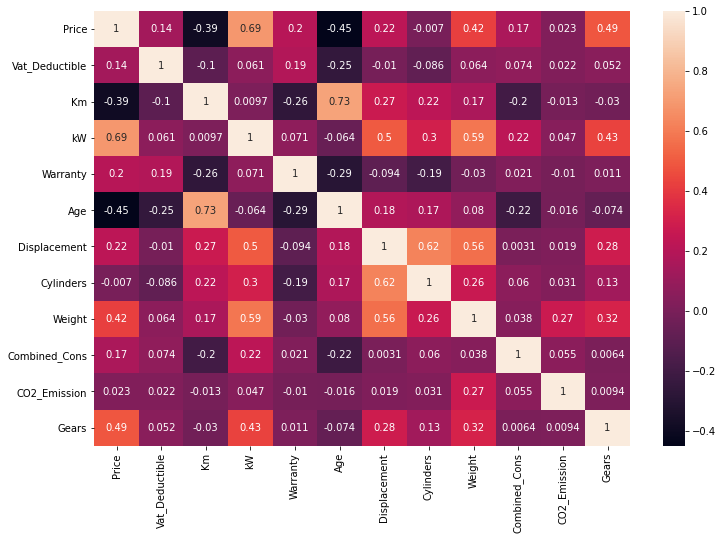

In [185]:
plt.figure(figsize = (12,8))
sns.heatmap(df1.corr(), annot = True);

In [186]:
df1.to_csv("clean_autoscout.csv", index=False)

---

_THE END!_